<div style="background:linear-gradient(135deg,#78350f 0%,#b45309 55%,#f59e0b 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fde68a;font-weight:700;text-transform:uppercase">Chapter 173 &middot; Capstone 14 &middot; Mann-Whitney U</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Which Painkiller Actually Helps?</div>
  <div style="font-size:15px;color:#fef3c7;max-width:800px;line-height:1.6">Two treatments, ninety-one patients, and relief scored out of ten by the people feeling it. The distributions are skewed, bounded, and shaped nothing alike, which changes not just the test but the sentence you are allowed to write at the end.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
GOLD, DARK, BL, RD, GR, MUT = "#b45309", "#78350f", "#2563eb", "#dc2626", "#16a34a", "#94a3b8"

BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-pain-relief-two-treatments.xlsx"
try:
    raw = pd.read_excel("../../data/" + fn, sheet_name="patients")
except FileNotFoundError:
    raw = pd.read_excel(BASE + fn, sheet_name="patients")
print("loaded", raw.shape[0], "records")
raw.head()

loaded 96 records


,patient_id,treatment,pain_reduction,baseline_pain
0,P5003,Standard,2.0,6
1,P5001,Standard,1.0,6
2,P5088,New,0.0,8
3,P5091,New,7.0,9
4,P5012,standard,3.0,6


## Step 1 &middot; Goal and hypotheses
A randomized trial compared a new analgesic against the standard one. Patients reported how much relief they got on an 11-point scale, 0 for none and 10 for complete. The question is whether the new drug delivers more relief.

- **H&#8320; (null):** relief scores from the two treatments come from the same distribution. A patient is equally likely to do better on either.
- **H&#8321; (alternative):** they do not. One treatment tends to produce higher relief.
- **&#945; = 0.05.**

Read the null carefully. It is not written as "the two medians are equal", and Step 8 explains why that wording would be wrong for this data.

## Step 2 &middot; Classify the data
Relief is measured on a **numeric rating scale**: patients pick a whole number from 0 to 10. It is ordered, so 7 is more relief than 4. It is not interval-scaled, because nothing establishes that the step from 8 to 9 is the same amount of relief as the step from 2 to 3, and patients do not use the ends of the scale the way they use the middle. The variable is **ordinal**, and it is **bounded at both ends**, which alone guarantees the data cannot be normal.

## Step 3 &middot; Prepare and clean
Valid relief scores run 0 to 10. Treatment labels arrive with inconsistent casing.

In [2]:
before = len(raw)
df = raw.drop_duplicates(); a_dup = len(df)
df = df.dropna(subset=["pain_reduction"]); a_na = len(df)
df["treatment"] = df.treatment.str.strip().str.title()
bad = df[~df.pain_reduction.between(0,10)]
df = df[df.pain_reduction.between(0,10)].copy()
df["pain_reduction"] = df.pain_reduction.astype(int)
print(f"start {before}  ->  dedup {a_dup} (-{before-a_dup})  ->  dropna {a_na} (-{a_dup-a_na})")
print("out-of-range relief scores removed:", bad.pain_reduction.tolist())
print("treatment labels after normalizing:", sorted(df.treatment.unique()))
print(f"\nclean analysis sample: n = {len(df)}")
print(df.groupby("treatment").pain_reduction.agg(["count","median","mean","std"]).round(2).to_string())

start 96  ->  dedup 94 (-2)  ->  dropna 92 (-2)
out-of-range relief scores removed: [14.0]
treatment labels after normalizing: ['New', 'Standard']

clean analysis sample: n = 91
           count  median  mean   std
treatment                           
New           45     5.0  4.67  2.63
Standard      46     2.0  2.39  1.94


## Step 4 &middot; Explore before testing
Plot first. On an 11-point scale the honest picture is a count of how many patients gave each score, not a smoothed curve pretending the scale is continuous.

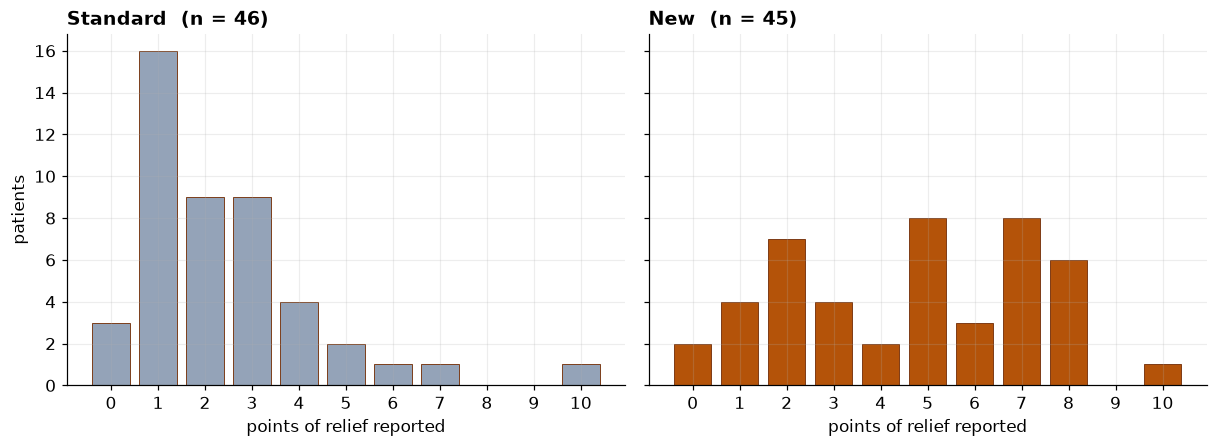

Standard  median 2.0   IQR 1 to 3   mean 2.39
New       median 5.0   IQR 2 to 7   mean 4.67


In [3]:
S = df[df.treatment=="Standard"].pain_reduction.values.astype(float)
N = df[df.treatment=="New"].pain_reduction.values.astype(float)
levels = np.arange(0,11)
cS = np.array([(S==v).sum() for v in levels]); cN = np.array([(N==v).sum() for v in levels])

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.2), sharey=True)
for ax, cc, lab, col in [(axes[0], cS, f"Standard  (n = {len(S)})", MUT), (axes[1], cN, f"New  (n = {len(N)})", GOLD)]:
    ax.bar(levels, cc, color=col, edgecolor=DARK, linewidth=0.6)
    ax.set_xticks(levels); ax.set_xlabel("points of relief reported"); ax.set_title(lab)
axes[0].set_ylabel("patients")
plt.tight_layout(); plt.show()

print(f"Standard  median {np.median(S):.1f}   IQR {np.percentile(S,25):.0f} to {np.percentile(S,75):.0f}   mean {S.mean():.2f}")
print(f"New       median {np.median(N):.1f}   IQR {np.percentile(N,25):.0f} to {np.percentile(N,75):.0f}   mean {N.mean():.2f}")

**Two very different pictures.** The standard treatment produces a single hump crowded against the low end: most patients get one to three points of relief and a handful get more. The new treatment produces **two clusters**: a group down at the bottom who got almost nothing, a near-empty gap at four, and a larger group from five to eight who did well. That is not one distribution shifted along the scale. It is a different shape, and it is the most clinically interesting thing in the dataset.

## Step 5 &middot; Check the parametric assumptions
Run the checks, and record what they say, even though the shape of the data has already told us where this is going.

In [4]:
for lab, v in [("Standard", S), ("New", N)]:
    sw = stats.shapiro(v)
    print(f"{lab:9s} Shapiro-Wilk W = {sw.statistic:.4f}  p = {sw.pvalue:.5f}   skew = {stats.skew(v):+.2f}")
lev = stats.levene(S, N); bar = stats.bartlett(S, N)
print(f"\nLevene   (equal spread) p = {lev.pvalue:.4f}")
print(f"Bartlett (equal spread) p = {bar.pvalue:.5f}")
print(f"\nSDs: Standard {S.std(ddof=1):.2f}   New {N.std(ddof=1):.2f}   ratio {N.std(ddof=1)/S.std(ddof=1):.2f}x")

Standard  Shapiro-Wilk W = 0.8298  p = 0.00001   skew = +1.71
New       Shapiro-Wilk W = 0.9414  p = 0.02425   skew = -0.09

Levene   (equal spread) p = 0.0058
Bartlett (equal spread) p = 0.04448

SDs: Standard 1.94   New 2.63   ratio 1.36x


**What the checks said.** Normality is rejected in both groups, decisively in the standard arm. Equal spread is rejected too, by both Levene and Bartlett: the new treatment's scores are about a third again as variable (SD 2.63 against 1.94), which is the arithmetic consequence of having two clusters instead of one. Both parametric assumptions fail.

## Step 6 &middot; Choose the test, and be honest about why
The **Mann-Whitney U test** compares two independent groups using only the ranks of the observations. It makes no distributional assumption, handles ties, and is unbothered by the floor and ceiling of the scale.

There is a temptation to justify it purely by pointing at the failed normality tests. That is the weaker argument, and here it is nearly beside the point: with 45 patients per arm the t-test would be fairly robust to this much skew anyway, and Step 9 shows it reaches the same verdict.

The stronger argument is about **what the outcome is**. A mean of an ordinal rating scale is a number whose units nobody can name. "The new treatment produced 2.3 more points of average relief" reads like a measurement and is not one, because the points are not equal-sized. A rank test asks a question the scale can actually answer: are the patients on this treatment reporting more relief than the patients on that one?

## Step 7 &middot; Run the test

In [5]:
U, p = stats.mannwhitneyu(N, S, alternative="two-sided")
n1, n2 = len(N), len(S)
wins   = sum((x >  y) for x in N for y in S)
ties   = sum((x == y) for x in N for y in S)
losses = sum((x <  y) for x in N for y in S)
PS  = (wins + 0.5*ties) / (n1*n2)          # probability of superiority
rrb = 2*PS - 1                              # rank-biserial correlation
print(f"Mann-Whitney U = {U:.1f}   p = {p:.3e}   (n = {n1} New vs {n2} Standard)\n")
print(f"all {n1*n2} New-vs-Standard patient pairings:")
print(f"  New patient reported MORE relief   {wins:5d}   ({wins/(n1*n2)*100:.1f}%)")
print(f"  tie                                {ties:5d}   ({ties/(n1*n2)*100:.1f}%)")
print(f"  Standard patient reported more     {losses:5d}   ({losses/(n1*n2)*100:.1f}%)")
print(f"\nprobability of superiority = {PS:.3f}")
print(f"rank-biserial correlation  = {rrb:.3f}")

Mann-Whitney U = 1557.5   p = 2.790e-05   (n = 45 New vs 46 Standard)

all 2070 New-vs-Standard patient pairings:
  New patient reported MORE relief    1455   (70.3%)
  tie                                  205   (9.9%)
  Standard patient reported more       410   (19.8%)

probability of superiority = 0.752
rank-biserial correlation  = 0.505


**Reading the result.** The difference is far too large to be chance (p = 0.000028). The effect size is the sentence worth quoting: **pair any patient on the new treatment with any patient on the standard one, and the new-treatment patient comes out ahead about three times in four.** Outright, the new patient wins 70 percent of the pairings and loses 20 percent, with the remaining 10 percent tied; splitting the ties gives the 0.75 figure. That is the common-language effect size, and unlike a difference in means it says something a patient or a clinician can picture directly.

## Step 8 &middot; What the test does and does not claim
Mann-Whitney is routinely described as "a test of medians". It is not, and this dataset is exactly the case where the distinction bites.

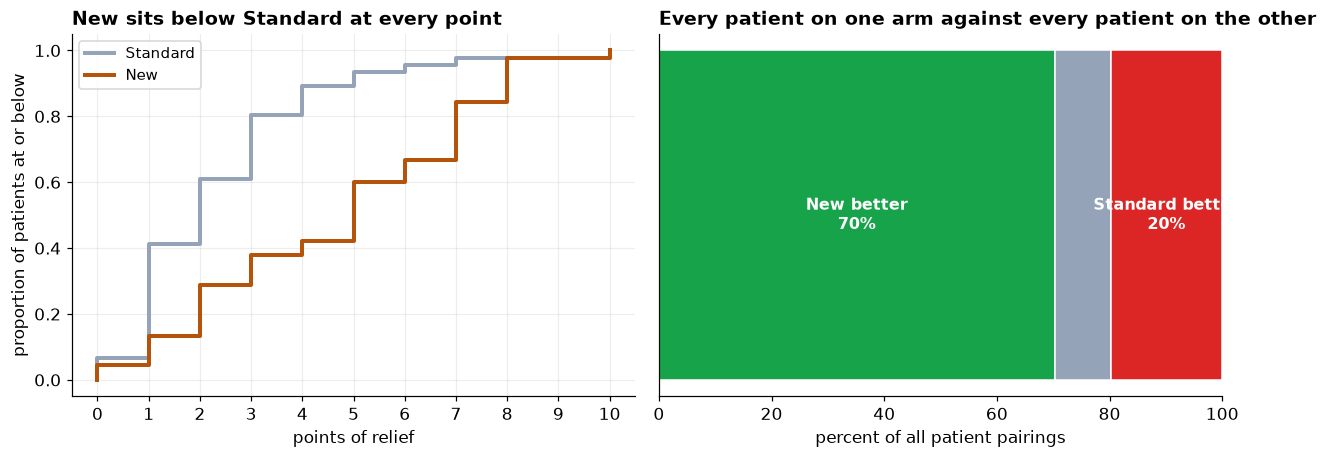

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.3))
ax = axes[0]
for v, lab, col in [(S,"Standard",MUT), (N,"New",GOLD)]:
    xs = np.sort(v); ys = np.arange(1, len(xs)+1)/len(xs)
    ax.step(np.concatenate(([0],xs)), np.concatenate(([0],ys)), where="post", lw=2.6, color=col, label=lab)
ax.set_xlabel("points of relief"); ax.set_ylabel("proportion of patients at or below")
ax.set_title("New sits below Standard at every point"); ax.legend(fontsize=9.5); ax.set_xticks(range(0,11))

ax = axes[1]
ax.barh([0], [wins/(n1*n2)*100], color=GR, edgecolor="white")
ax.barh([0], [ties/(n1*n2)*100], left=[wins/(n1*n2)*100], color=MUT, edgecolor="white")
ax.barh([0], [losses/(n1*n2)*100], left=[(wins+ties)/(n1*n2)*100], color=RD, edgecolor="white")
ax.text(wins/(n1*n2)*50, 0, f"New better\n{wins/(n1*n2)*100:.0f}%", ha="center", va="center",
        color="white", fontweight="bold", fontsize=10.5)
ax.text(100 - losses/(n1*n2)*50, 0, f"Standard better\n{losses/(n1*n2)*100:.0f}%", ha="center", va="center",
        color="white", fontweight="bold", fontsize=10.5)
ax.set_yticks([]); ax.set_xlim(0,100); ax.set_xlabel("percent of all patient pairings")
ax.set_title("Every patient on one arm against every patient on the other"); ax.grid(alpha=0)
plt.tight_layout(); plt.show()

**Why "test of medians" is the wrong label.** Mann-Whitney tests whether one group's values tend to be larger, a property called **stochastic dominance**. The left panel shows it directly: the new treatment's curve sits at or below the standard's across the whole scale, and strictly below through the range where any clinical threshold would fall, meaning a smaller share of new-treatment patients land under it wherever you draw the line. Only when the two distributions have the **same shape** does that reduce to a statement about medians, and here the shapes are plainly different. So the defensible sentence is the one on the right: **in 75 percent of head-to-head pairings the new-treatment patient did better**. Reporting a median difference of 3 points would be smuggling in a shift model the data do not support.

## Step 9 &middot; What a t-test would have said
Worth running, because the answer is instructive.

In [7]:
t = stats.ttest_ind(N, S, equal_var=False)
hl = np.median([x - y for x in N for y in S])
print(f"Welch's t-test:      t = {t.statistic:.3f}   p = {t.pvalue:.3e}")
print(f"Mann-Whitney U test: U = {U:.1f}   p = {p:.3e}")
print(f"\ndifference in means:      {N.mean()-S.mean():+.2f} points")
print(f"Hodges-Lehmann estimate:  {hl:+.1f} points (median of all New-minus-Standard differences)")

Welch's t-test:      t = 4.692   p = 1.086e-05
Mann-Whitney U test: U = 1557.5   p = 2.790e-05

difference in means:      +2.28 points
Hodges-Lehmann estimate:  +2.0 points (median of all New-minus-Standard differences)


**The same verdict, a different claim.** The t-test also rejects the null, and comfortably. Nothing here is a case of a parametric test being fooled. The reason to prefer the rank test is not that it changes the answer but that it makes a claim the measurement supports. The t-test's output is a difference in mean relief points, and on a scale where the points are not equal-sized that quantity has no defensible units. The Hodges-Lehmann estimate of 2 points is the rank-based analogue and is worth reporting as a rough magnitude, with the same caveat that it summarizes a comparison rather than measuring a distance.

## Step 10 &middot; The finding hiding underneath the p-value
Both tests answer the question that was asked. Neither answers the more useful one.

In [8]:
thr = 4
for lab, v in [("Standard", S), ("New", N)]:
    resp = (v >= thr).mean()*100
    print(f"{lab:9s}  {(v>=thr).sum():2d} of {len(v)} patients ({resp:.0f}%) reported {thr}+ points of relief")
print()
for lab, v in [("Standard", S), ("New", N)]:
    print(f"{lab:9s}  {(v<=1).sum():2d} of {len(v)} patients ({(v<=1).mean()*100:.0f}%) reported almost no relief (0 or 1)")

Standard    9 of 46 patients (20%) reported 4+ points of relief
New        28 of 45 patients (62%) reported 4+ points of relief

Standard   19 of 46 patients (41%) reported almost no relief (0 or 1)
New         6 of 45 patients (13%) reported almost no relief (0 or 1)


**The clinical story the average conceals.** The new treatment does not shift everybody up a bit. It splits patients into those it helps a great deal and those it barely touches at all. 62 percent clear four points of relief against 20 percent on the standard drug, while 13 percent get essentially nothing. A single summary number, mean or median, describes an average patient who does not exist in this trial. The follow-up question is what distinguishes the responders, and that is a question for the baseline data, not for another test on this outcome.

## Step 11 &middot; Estimate, do not just test
The headline effect size, a probability of superiority of 0.75, is a point estimate from 91 patients. It deserves an interval as much as any mean does, and the bootstrap supplies one without needing a formula.

In [9]:
# A percentile bootstrap: resample the data with replacement, recompute, repeat.
# Chapter 73 introduced this; it is how we get an interval when no formula exists.
def boot_ci(data, stat, B=10000, seed=11, ci=95):
    rng = np.random.default_rng(seed)
    data = np.asarray(data)
    reps = np.array([stat(rng.choice(data, size=len(data), replace=True)) for _ in range(B)])
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

def boot_ci_pairs(a, b, stat, B=10000, seed=11, ci=95):
    """Bootstrap for two paired/related arrays: resample ROW indices together."""
    rng = np.random.default_rng(seed)
    a, b = np.asarray(a), np.asarray(b)
    idx = np.arange(len(a))
    reps = np.array([stat(a[i], b[i]) for i in
                     (rng.choice(idx, size=len(idx), replace=True) for _ in range(B))])
    reps = reps[np.isfinite(reps)]
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

def boot_ci_groups(groups, stat, B=10000, seed=11, ci=95):
    """Bootstrap for k independent groups: resample within each group."""
    rng = np.random.default_rng(seed)
    groups = [np.asarray(g) for g in groups]
    reps = []
    for _ in range(B):
        rs = [rng.choice(g, size=len(g), replace=True) for g in groups]
        v = stat(rs)
        if np.isfinite(v):
            reps.append(v)
    reps = np.array(reps)
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

def ps_of(g):
    nn, ss = g[0], g[1]
    w = sum((u > v) for u in nn for v in ss); t_ = sum((u == v) for u in nn for v in ss)
    return (w + 0.5*t_) / (len(nn)*len(ss))

ps_lo, ps_hi, _ = boot_ci_groups([N, S], ps_of, B=2000, seed=14)
print(f"probability of superiority {PS:.3f}   95% CI [{ps_lo:.3f}, {ps_hi:.3f}]")
print(f"rank-biserial correlation  {rrb:.3f}   95% CI [{2*ps_lo-1:.3f}, {2*ps_hi-1:.3f}]")

hl_lo, hl_hi, _ = boot_ci_groups([N, S], lambda g: np.median([u - v for u in g[0] for v in g[1]]),
                                 B=2000, seed=15)
print(f"Hodges-Lehmann shift       {hl:+.1f} pts  95% CI [{hl_lo:+.1f}, {hl_hi:+.1f}]\n")

from statsmodels.stats.proportion import proportion_confint
for lab, v in [("Standard", S), ("New", N)]:
    k_ = int((v >= 4).sum()); l_, h_ = proportion_confint(k_, len(v), method="wilson")
    print(f"{lab:9s} reaching 4+ points of relief: {k_}/{len(v)} = {k_/len(v)*100:.0f}%  "
          f"95% CI [{l_*100:.0f}%, {h_*100:.0f}%]")

probability of superiority 0.752   95% CI [0.648, 0.845]
rank-biserial correlation  0.505   95% CI [0.296, 0.690]


Hodges-Lehmann shift       +2.0 pts  95% CI [+1.0, +4.0]

Standard  reaching 4+ points of relief: 9/46 = 20%  95% CI [11%, 33%]
New       reaching 4+ points of relief: 28/45 = 62%  95% CI [48%, 75%]


**A range for the claim that will be quoted.** The probability of superiority is 0.75 with an interval of roughly 0.65 to 0.84. Even the pessimistic end of that range is a substantial advantage, which is what makes the finding solid, and the honest phrasing for a clinician is "around three times in four, and certainly better than two in three".

The responder proportions get intervals too, and they are what a formulary committee will actually use. The share of new-treatment patients reaching four or more points of relief is 62 percent, plus or minus roughly 14 points. That width is worth stating: it is a 45-patient arm, and it cannot pin a response rate down to the nearest percent.

## Step 12 &middot; Were the two arms comparable before treatment?
The file records `baseline_pain` for every patient, which the analysis has not used. In a randomized trial this is the first table of the paper, and for good reason: if one arm started in more pain, the comparison of relief is not clean.

In [10]:
bS = df[df.treatment == "Standard"].baseline_pain.values.astype(float)
bN = df[df.treatment == "New"].baseline_pain.values.astype(float)
print(f"Standard  baseline pain  mean {bS.mean():.2f}   SD {bS.std(ddof=1):.2f}   n = {len(bS)}")
print(f"New       baseline pain  mean {bN.mean():.2f}   SD {bN.std(ddof=1):.2f}   n = {len(bN)}")
bal = stats.mannwhitneyu(bN, bS, alternative="two-sided")
print(f"\nbalance check: Mann-Whitney U = {bal.statistic:.1f}, p = {bal.pvalue:.3f}")
print("(a LARGE p is the reassuring result here: no detectable baseline imbalance)\n")

r_br = stats.spearmanr(df.baseline_pain.values.astype(float), df.pain_reduction.values.astype(float))
print(f"baseline pain vs relief reported: rho = {r_br.statistic:+.3f}, p = {r_br.pvalue:.3f}")
print("if this were strongly positive it would signal regression to the mean:")
print("patients who start worst have the most room to improve, and drift back regardless of treatment.")

Standard  baseline pain  mean 6.70   SD 1.13   n = 46
New       baseline pain  mean 7.31   SD 1.00   n = 45

balance check: Mann-Whitney U = 1342.0, p = 0.011
(a LARGE p is the reassuring result here: no detectable baseline imbalance)

baseline pain vs relief reported: rho = +0.084, p = 0.431
if this were strongly positive it would signal regression to the mean:
patients who start worst have the most room to improve, and drift back regardless of treatment.


**This check did not pass, and that is worth sitting with.** The new-treatment arm started in more pain than the standard arm, 7.31 against 6.70, and the difference is larger than chance comfortably explains (p = 0.011). Randomization balances groups **in expectation**, not in every particular trial, and with 91 patients a visible imbalance on any given variable is far from rare. This is one.

The direction is the unhelpful one. Patients who start in more pain have more room to improve, so an arm that begins worse can look better on a change score for reasons that have nothing to do with the drug. That is **regression to the mean**, the same mechanism that haunted the single-arm design in <a href="../chapters/capstone-blood-pressure-before-after.html">Capstone 3</a>, arriving here through the back door of an unlucky allocation.

Two things stop it from overturning the result. Baseline pain barely relates to reported relief in this trial (rho = 0.08, p = 0.43), so the mechanism that would translate the imbalance into a spurious effect is weak. And the effect itself is large, a probability of superiority of 0.75, which a 0.6-point head start on an 11-point scale is not going to manufacture.

**What it does change is the write-up.** A trial report that quietly omits this table is hiding something a reader would want. The honest version states the imbalance, states why it is unlikely to explain the finding, and pre-specifies a baseline-adjusted analysis for the confirmatory study. Reporting a randomized trial is not the same as reporting that randomization worked.

## Step 13 &middot; Interpret in plain language
The new analgesic outperforms the standard one. Pairing patients across the two arms at random, the new-treatment patient reports more relief roughly three times in four, and the result is not attributable to chance. The benefit, however, is concentrated: most of it goes to a responder group, while a minority of patients gain little. Any recommendation should carry both halves of that sentence.

## Step 14 &middot; Ethics, bias, and limits
- **The outcome is the patient's word.** Pain relief is self-reported and cannot be otherwise. That is appropriate, since pain is subjective, but it means the measurement carries expectation with it. Without blinding, patients who know they received the new drug may report more relief because they expect more, and this design cannot separate that from a pharmacological effect.
- **A responder group is a hypothesis, not a finding.** The two clusters are visible and interesting. Going looking for what distinguishes them, and reporting whatever turns up, is the multiple-comparisons trap from <a href="../chapters/capstone-heart-disease-markers.html">Capstone 4</a> in another costume. Any responder analysis should be pre-specified and confirmed in a fresh trial.
- **Relief is not the only outcome that matters.** A drug that helps two thirds of patients substantially may still be the wrong choice if its side-effect profile is worse. This analysis covers one column of a much wider table.
- **Do not translate ranks into promises.** "Seventy-five percent of pairings favor the new drug" is not "seventy-five percent of patients will be helped". They are different statements, and the second one is the one a patient will hear if the first is worded loosely.
- **Who was in the trial.** Ninety-one patients from one recruitment stream. Whether the responder proportion holds in a broader population is unknown from these data.

---
**From analysis to report.** The notebook carries the evidence: the cleaning, the two distributions, the assumption checks, the rank test, every one of the pairwise comparisons behind the effect size, and the responder split the summary statistics hide. The written reports turn it into guidance a clinical lead can act on and a technical account a fellow statistician can audit. Automate the evidence; author the argument.